# Exercícios: Cadeias de Markov e MDP

Neste notebook você vai praticar os conceitos vistos em aula:

- Construir e interpretar uma **Matriz de Transição**
- Simular trajetórias em uma **Cadeia de Markov**
- Calcular a **Equação de Bellman** manualmente
- Implementar o algoritmo de **Value Iteration**
- Analisar o impacto do fator de desconto **γ (gamma)**

Cada exercício tem um espaço `# SEU CÓDIGO AQUI` e uma dica oculta disponível.

---

**Conceitos-chave:**

| Símbolo | Nome | Significado |
|---------|------|-------------|
| `P` | Matriz de Transição | Probabilidade de ir do estado `i` para o estado `j` |
| `V(s)` | Função de Valor | Recompensa esperada acumulada a partir do estado `s` |
| `γ` | Gamma | Quanto o agente valoriza recompensas futuras (0 a 1) |
| `δ` | Delta | Variação máxima em V entre iterações (critério de parada) |

## Importações — execute antes de tudo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Parte 1 — Cadeias de Markov

Vamos modelar o comportamento de um **estudante** ao longo de uma semana.
Em cada dia, ele pode estar em um de três estados:

- **Estado 0**: Estudando 📚
- **Estado 1**: Descansando 🛋️
- **Estado 2**: Jogando videogame 🎮

---
## Exercício 1 — Construindo a Matriz de Transição

Complete a matriz de transição `P` com as seguintes regras de comportamento do estudante:

| De \ Para | Estudando | Descansando | Jogando |
|-----------|-----------|-------------|--------|
| **Estudando** | 0.5 | 0.3 | 0.2 |
| **Descansando** | 0.4 | 0.4 | 0.2 |
| **Jogando** | ??? | 0.3 | 0.5 |

**Regra obrigatória:** cada linha deve somar **exatamente 1.0** (probabilidades totais).

Descubra o valor `???` e complete a linha do estado **Jogando**.

In [11]:
estados = ['📚 Estudando', '🛋️ Descansando', '🎮 Jogando']

P = np.array([
    [0.5, 0.3, 0.2],   # De Estudando para: Estudando, Descansando, Jogando
    [0.4, 0.4, 0.2],   # De Descansando para: Estudando, Descansando, Jogando
    [0.2, 0.3, 0.5]    # De Jogando para: Estudando, Descansando, Jogando
                       # SEU CÓDIGO AQUI: substitua ??? pelo valor correto
])

# Verificação automática:
print("Soma de cada linha (deve ser 1.0):")
for i, estado in enumerate(estados):
    soma = P[i].sum()
    ok = "✅" if abs(soma - 1.0) < 1e-9 else "❌"
    print(f"  {estado}: {soma:.2f} {ok}")

Soma de cada linha (deve ser 1.0):
  📚 Estudando: 1.00 ✅
  🛋️ Descansando: 1.00 ✅
  🎮 Jogando: 1.00 ✅


<details>
<summary>Dica</summary>

A linha do estado Jogando deve somar 1.0:
```
??? + 0.3 + 0.5 = 1.0
??? = 1.0 - 0.3 - 0.5
```
</details>

---
## Exercício 2 — Simulando uma Trajetória

Implemente a função `simular_cadeia(P, estado_inicial, num_passos)` que:

1. Começa no `estado_inicial`
2. A cada passo, sorteia o próximo estado com base em `P[estado_atual]`
3. Retorna a lista de estados visitados (incluindo o inicial)

> **Dica:** use `np.random.choice(n_estados, p=P[estado_atual])` para sortear o próximo estado.

In [12]:
def simular_cadeia(P, estado_inicial=0, num_passos=7):
    """
    Simula uma trajetória na Cadeia de Markov.

    Parâmetros:
        P             : matriz de transição
        estado_inicial: índice do estado de partida
        num_passos    : quantidade de transições a realizar

    Retorna:
        trajetoria: lista de índices de estados visitados
    """
    trajetoria = [estado_inicial]
    estado_atual = estado_inicial

    for _ in range(num_passos):
        # SEU CÓDIGO AQUI:
        # 1. Sorteie o próximo estado usando P[estado_atual]
        # 2. Adicione-o à trajetória
        # 3. Atualize estado_atual
        proximo_estado = np.random.choice(len(P), p=P[estado_atual])
        trajetoria.append(proximo_estado)
        estado_atual = proximo_estado
    return trajetoria


# Corrige a matriz P do Exercício 1, garantindo que a linha de "Jogando" some 1.0
#P[2, 0] = 1.0 - P[2, 1] - P[2, 2] # Deve ser 0.2

# Teste: simule 3 trajetórias de 7 dias
print("3 simulações de 7 dias, partindo de 📚 Estudando:\n")
for i in range(3):
    traj = simular_cadeia(P, estado_inicial=0, num_passos=7)
    sequencia = " → ".join([estados[s] for s in traj])
    print(f"Simulação {i+1}: {sequencia}")

3 simulações de 7 dias, partindo de 📚 Estudando:

Simulação 1: 📚 Estudando → 📚 Estudando → 📚 Estudando → 📚 Estudando → 📚 Estudando → 📚 Estudando → 📚 Estudando → 🛋️ Descansando
Simulação 2: 📚 Estudando → 📚 Estudando → 🛋️ Descansando → 📚 Estudando → 🎮 Jogando → 🎮 Jogando → 🛋️ Descansando → 🛋️ Descansando
Simulação 3: 📚 Estudando → 📚 Estudando → 🎮 Jogando → 🎮 Jogando → 📚 Estudando → 📚 Estudando → 📚 Estudando → 📚 Estudando


<details>
<summary>Dica</summary>

```python
proximo_estado = np.random.choice(len(P), p=P[estado_atual])
trajetoria.append(proximo_estado)
estado_atual = proximo_estado
```
</details>

---
## Exercício 3 — Frequência dos Estados

Execute **500 simulações** de 30 passos cada (partindo do estado 0) e calcule:

1. Quantas vezes cada estado apareceu no total
2. A frequência relativa (%) de cada estado
3. Exiba um gráfico de barras com os resultados

> Isso estima a **distribuição estacionária** da cadeia — o comportamento de longo prazo.

Distribuição estimada dos estados (longo prazo):
---------------------------------------------
📚 Estudando         :  40.2% ████████████████████
🛋️ Descansando      :  32.6% ████████████████
🎮 Jogando           :  27.2% █████████████


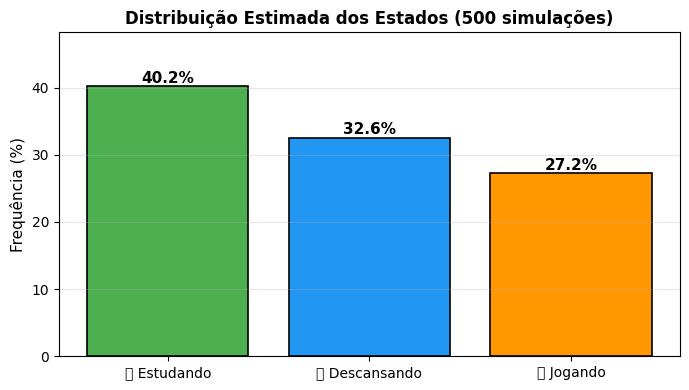

In [13]:
n_simulacoes = 500
n_passos = 30

# Contador de ocorrências
contagem = [0, 0, 0]

for _ in range(n_simulacoes):
    # SEU CÓDIGO AQUI:
    # 1. Simule uma trajetória com simular_cadeia
    # 2. Para cada estado na trajetória, incremente contagem[estado]
    traj = simular_cadeia(P, estado_inicial=0, num_passos=n_passos)
    for estado in traj:
        contagem[estado] += 1

total = sum(contagem)

print("Distribuição estimada dos estados (longo prazo):")
print("-" * 45)
for i, estado in enumerate(estados):
    pct = contagem[i] / total * 100
    barra = "█" * int(pct / 2)
    print(f"{estado:20s}: {pct:5.1f}% {barra}")

# Gráfico de barras
cores = ['#4CAF50', '#2196F3', '#FF9800']
frequencias = [c / total * 100 for c in contagem]

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(estados, frequencias, color=cores, edgecolor='black', linewidth=1.2)

for barra, pct in zip(barras, frequencias):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Frequência (%)', fontsize=11)
ax.set_title('Distribuição Estimada dos Estados (500 simulações)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(frequencias) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<details>
<summary> Dica</summary>

```python
for _ in range(n_simulacoes):
    traj = simular_cadeia(P, estado_inicial=0, num_passos=n_passos)
    for estado in traj:
        contagem[estado] += 1
```
</details>

---
## Exercício 4 — Visualizando Trajetórias

Gere **3 trajetórias** de 10 passos e plote-as em um gráfico de linhas, onde:
- O eixo X representa o dia (passo)
- O eixo Y representa o estado (0, 1 ou 2)
- Cada trajetória é uma linha diferente
- O eixo Y deve mostrar os **nomes dos estados**, não os números

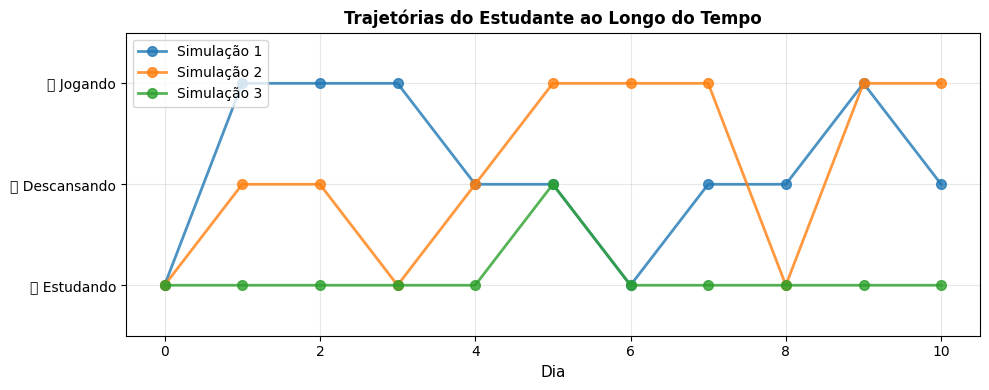

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

for i in range(3):
    # SEU CÓDIGO AQUI:
    # 1. Simule uma trajetória de 10 passos
    # 2. Plote com ax.plot(dias, trajetória, 'o-', label=...)
    traj = simular_cadeia(P, estado_inicial=0, num_passos=10)
    dias = range(len(traj))
    ax.plot(dias, traj, 'o-', linewidth=2, markersize=7,
            label=f'Simulação {i+1}', alpha=0.8)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(estados, fontsize=10)
ax.set_xlabel('Dia', fontsize=11)
ax.set_title('Trajetórias do Estudante ao Longo do Tempo', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 2.5)
plt.tight_layout()
plt.show()

<details>
<summary>Dica</summary>

```python
for i in range(3):
    traj = simular_cadeia(P, estado_inicial=0, num_passos=10)
    dias = range(len(traj))
    ax.plot(dias, traj, 'o-', linewidth=2, markersize=7,
            label=f'Simulação {i+1}', alpha=0.8)
```
</details>

---
# Parte 2 — MDP e Equação de Bellman

Agora vamos trabalhar com um **labirinto** onde o agente precisa chegar ao objetivo (★).

**Legenda do mapa:**
- `1` → Parede
- `0` → Célula livre
- `9` → Objetivo ★

**Regra de transição:**
- **80%** de chance de ir para onde planejou
- **20%** de chance de ficar no mesmo lugar

---
## Exercício 5 — Definindo o Ambiente MDP

Execute a célula abaixo para criar o labirinto e a função de visualização.
Depois responda: **quantos estados livres existem?** (células com valor 0)

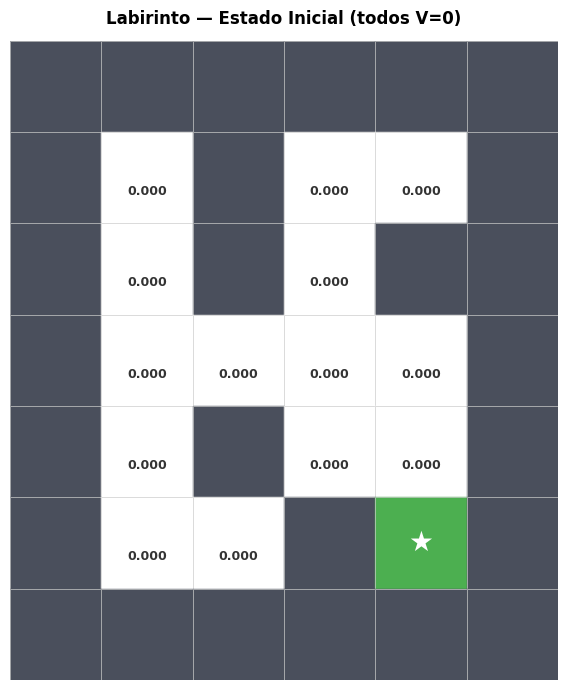

Paredes:        27
Objetivo:       1
Estados livres: 14


In [16]:
# Labirinto: 1=Parede, 0=Livre, 9=Objetivo
maze = np.array([
    [1, 1, 1, 1, 1, 1],
    [1, 0, 1, 0, 0, 1],
    [1, 0, 1, 0, 1, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 1],
    [1, 0, 0, 1, 9, 1],
    [1, 1, 1, 1, 1, 1]
])

num_rows, num_cols = maze.shape

# Parâmetros do MDP
gamma     = 0.9
p_sucesso = 0.8
p_falha   = 0.2


def plot_maze(V, title='Labirinto', policy=None):
    """Visualiza o labirinto com os valores V(s) e setas da política."""
    fig, ax = plt.subplots(figsize=(6, 7))
    arrows = {'up': '↑', 'down': '↓', 'left': '←', 'right': '→'}

    for row in range(num_rows):
        for col in range(num_cols):
            val = maze[row, col]
            if val == 1:
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color='#4a4f5c'))
            elif val == 9:
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color='#4CAF50'))
                ax.text(col+0.5, num_rows-row-0.5, '★',
                        ha='center', va='center', fontsize=20, color='white', fontweight='bold')
            else:
                v = V[row, col]
                intensity = min(max(v, 0), 1)
                r = int(255*(1-intensity*0.87))
                g = int(255*(1-intensity*0.41))
                color = f'#{r:02x}{g:02x}ff'
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color=color))
                txt_c = 'white' if intensity > 0.6 else '#333333'
                ax.text(col+0.5, num_rows-row-0.65, f'{v:.3f}',
                        ha='center', va='center', fontsize=9, color=txt_c, fontweight='bold')
                if policy and (row, col) in policy:
                    ax.text(col+0.5, num_rows-row-0.35, arrows[policy[(row, col)]],
                            ha='center', va='center', fontsize=15, color=txt_c, alpha=0.8)
            ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1,
                                       fill=False, edgecolor='#cccccc', linewidth=0.5))

    ax.set_xlim(0, num_cols)
    ax.set_ylim(0, num_rows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()


# Visualize o labirinto vazio
V_zero = np.zeros((num_rows, num_cols))
plot_maze(V_zero, title='Labirinto — Estado Inicial (todos V=0)')

# SEU CÓDIGO AQUI: imprima o número de estados livres (células == 0)
print(f"Paredes:        {np.sum(maze == 1)}")
print(f"Objetivo:       {np.sum(maze == 9)}")
print(f"Estados livres: {np.sum(maze == 0)}")  # substitua ??? pela expressão correta

<details>
<summary> Dica</summary>

```python
print(f"Estados livres: {np.sum(maze == 0)}")
```
</details>

---
## Exercício 6 — Equação de Bellman

Complete a função `calcular_valor(estado, acao, V)` que implementa a Equação de Bellman:

$$V(s) = \gamma \cdot \big[ p_{sucesso} \cdot V(s') + p_{falha} \cdot V(s) \big]$$

Onde:
- `s'` = próximo estado se a ação for bem-sucedida
- Se `s'` for parede, o agente fica em `s`
- Se `s` for o objetivo (`9`), retorne `1.0` diretamente

| Ação | Efeito |
|------|--------|
| `'up'` | `row - 1` |
| `'down'` | `row + 1` |
| `'left'` | `col - 1` |
| `'right'` | `col + 1` |

In [18]:
def calcular_valor(estado, acao, V):
    """
    Calcula o valor de Bellman para (estado, ação).

    Parâmetros:
        estado : (row, col)
        acao   : 'up' | 'down' | 'left' | 'right'
        V      : matriz de valores atual

    Retorna:
        float: valor esperado
    """
    row, col = estado

    # Estados especiais
    if maze[row, col] == 9:  return 1.0   # Objetivo: recompensa máxima
    if maze[row, col] == 1:  return 0.0   # Parede: inválido

    # Calcula o próximo estado (padrão: fica no lugar)
    proximo = (row, col)

    # SEU CÓDIGO AQUI:
    # Calcule 'proximo' com base na ação
    # Use max/min para não sair dos limites do mapa
    if acao == 'up': proximo = max(row - 1, 0), col

    elif acao == 'down': proximo = min(row + 1, num_rows - 1), col

    elif acao == 'left':
        proximo = row, max(col - 1, 0)
    elif acao == 'right':
        proximo = row, min(col + 1, num_cols - 1)

    # Se próximo estado for parede, volta para o estado atual
    if maze[proximo[0], proximo[1]] == 1:
        proximo = (row, col)

    # SEU CÓDIGO AQUI:
    # Aplique a Equação de Bellman:
    # valor = gamma * (p_sucesso * V[proximo] + p_falha * V[estado_atual])
    valor = gamma * (p_sucesso * V[proximo[0], proximo[1]] + p_falha * V[row,col])

    return valor


# Teste com V zerado (resultado deve ser 0.0 para todos)
V_teste = np.zeros((num_rows, num_cols))
print("Teste com V zerado (todos devem ser 0.0):")
for a in ['up', 'down', 'left', 'right']:
    v = calcular_valor((3, 1), a, V_teste)
    print(f"  Ação '{a:5s}' → {v:.4f}")

Teste com V zerado (todos devem ser 0.0):
  Ação 'up   ' → 0.0000
  Ação 'down ' → 0.0000
  Ação 'left ' → 0.0000
  Ação 'right' → 0.0000


<details>
<summary> Dica</summary>

Para calcular o próximo estado:
```python
if acao == 'up':
    proximo = (max(row - 1, 0), col)
elif acao == 'down':
    proximo = (min(row + 1, num_rows - 1), col)
elif acao == 'left':
    proximo = (row, max(col - 1, 0))
elif acao == 'right':
    proximo = (row, min(col + 1, num_cols - 1))
```

Para a equação de Bellman:
```python
valor = gamma * (p_sucesso * V[proximo[0], proximo[1]] +
                 p_falha   * V[row, col])
```
</details>

---
## Exercício 7 — Melhor Ação

Implemente `melhor_acao(estado, V)` que:
1. Testa as 4 ações possíveis usando `calcular_valor`
2. Retorna a ação com **maior valor** e o valor correspondente

In [19]:
def melhor_acao(estado, V):
    """
    Retorna a melhor ação e seu valor para um estado.

    Retorna:
        (acao_str, valor_float)
    """
    acoes = ['up', 'down', 'left', 'right']

    # SEU CÓDIGO AQUI:
    # Itere sobre as ações, calcule o valor de cada uma,
    # e retorne a ação com maior valor
    melhor_v = -float('inf')
    melhor_a = None

    for acao in acoes:
        pass  # substitua por sua implementação

    return melhor_a, melhor_v


# Teste: V ainda zerado — todos os valores serão iguais
a, v = melhor_acao((3, 1), V_teste)
print(f"Estado (3,1) com V zerado → melhor ação: {a}, valor: {v:.4f}")
print("(Com V zerado, qualquer ação tem valor 0 — resultado esperado)")

Estado (3,1) com V zerado → melhor ação: None, valor: -inf
(Com V zerado, qualquer ação tem valor 0 — resultado esperado)


<details>
<summary> Dica</summary>

```python
for acao in acoes:
    v = calcular_valor(estado, acao, V)
    if v > melhor_v:
        melhor_v = v
        melhor_a = acao
```
</details>

---
##  Exercício 8 — Value Iteration (1 iteração manual)

Implemente **uma iteração** do algoritmo de Value Iteration:

1. Para cada célula não-parede do labirinto:
   - Calcule a melhor ação com `melhor_acao`
   - Armazene o novo valor em `novo_V`
   - Se for célula livre (`== 0`), armazene a ação na política
   - Calcule o `delta`: variação máxima entre `V` antigo e novo
2. Substitua `V` por `novo_V`
3. Visualize com `plot_maze`

> Execute esta célula **várias vezes** para ver os valores se propagando pelo labirinto!

In [20]:
# Execute esta célula para resetar
V = np.zeros((num_rows, num_cols))
iteracao_atual = 0
print("Resetado! Agora execute a célula abaixo repetidamente.")

Resetado! Agora execute a célula abaixo repetidamente.


In [ ]:
# Execute esta célula várias vezes — cada execução é uma iteração

delta   = 0
novo_V  = V.copy()
politica = {}

for row in range(num_rows):
    for col in range(num_cols):
        if maze[row, col] != 1:   # Ignora paredes
            v_antigo = V[row, col]

            # SEU CÓDIGO AQUI:
            # 1. Chame melhor_acao((row, col), V)
            # 2. Armazene o novo valor em novo_V[row, col]
            # 3. Se maze[row,col] == 0, guarde a ação em politica[(row, col)]
            # 4. Atualize delta = max(delta, |v_antigo - novo_valor|)
            pass

V = novo_V
iteracao_atual += 1

print(f"Iteração {iteracao_atual:3d} | Delta máximo: {delta:.6f}")
print("(Quando delta ≈ 0, o algoritmo convergiu)")
plot_maze(V, title=f'Iteração {iteracao_atual}  |  Delta = {delta:.5f}', policy=politica)

<details>
<summary> Dica</summary>

```python
acao, valor = melhor_acao((row, col), V)
novo_V[row, col] = valor
if maze[row, col] == 0:
    politica[(row, col)] = acao
delta = max(delta, abs(v_antigo - valor))
```
</details>

---
##  Exercício 9 — Convergência Completa

Agora implemente o loop completo do Value Iteration que roda até convergir.

O critério de parada é: **delta < 1e-6**

Além de convergir, guarde o histórico de deltas em `historico_delta` para visualizar a curva de aprendizado.

In [ ]:
V = np.zeros((num_rows, num_cols))
historico_delta = []
iteracao = 0
threshold = 1e-6

print("Iniciando Value Iteration...")
print("=" * 45)

# SEU CÓDIGO AQUI:
# Implemente o loop while que:
# 1. Faz uma iteração completa sobre todos os estados
# 2. Calcula o delta máximo
# 3. Guarda delta em historico_delta
# 4. Para quando delta < threshold
# 5. Imprime o progresso a cada 10 iterações

while True:
    pass  # substitua pelo seu loop

print("=" * 45)
print(f"\nTotal de iterações: {iteracao}")
print(f"Delta final: {delta:.2e}")

plot_maze(V, title=f'Política Ótima — convergiu em {iteracao} iterações', policy=politica)

<details>
<summary> Dica</summary>

```python
while True:
    delta = 0
    novo_V = V.copy()
    politica = {}

    for row in range(num_rows):
        for col in range(num_cols):
            if maze[row, col] != 1:
                v_antigo = V[row, col]
                acao, valor = melhor_acao((row, col), V)
                novo_V[row, col] = valor
                if maze[row, col] == 0:
                    politica[(row, col)] = acao
                delta = max(delta, abs(v_antigo - valor))

    V = novo_V
    iteracao += 1
    historico_delta.append(delta)

    if iteracao % 10 == 0 or delta < threshold:
        print(f'Iteração {iteracao:3d} | Delta: {delta:.8f}')

    if delta < threshold:
        break
```
</details>

---
## Exercício 10 — Curva de Convergência

Usando o `historico_delta` gerado no exercício anterior, plote **dois gráficos lado a lado**:

1. **Escala linear** — delta vs. iteração
2. **Escala logarítmica** — `ax.semilogy(...)` — que revela a queda exponencial

Adicione uma linha horizontal tracejada vermelha no limiar `1e-6`.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# SEU CÓDIGO AQUI:
# Gráfico 1 (axes[0]): escala linear com axes[0].plot(...)
# Gráfico 2 (axes[1]): escala log com axes[1].semilogy(...)
# Em ambos: linha tracejada no threshold (1e-6)

for ax in axes:
    ax.set_xlabel('Iteração', fontsize=11)
    ax.set_ylabel('Delta máximo', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Convergência (escala linear)', fontsize=12, fontweight='bold')
axes[1].set_title('Convergência (escala logarítmica)', fontsize=12, fontweight='bold')

plt.suptitle('O delta cai exponencialmente → o algoritmo sempre converge',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

<details>
<summary> Dica</summary>

```python
axes[0].plot(historico_delta, color='#2196F3', linewidth=2, label='Delta')
axes[0].axhline(y=1e-6, color='red', linestyle='--', label='Limiar (1e-6)')

axes[1].semilogy(historico_delta, color='#4CAF50', linewidth=2, label='Delta (log)')
axes[1].axhline(y=1e-6, color='red', linestyle='--', label='Limiar (1e-6)')
```
</details>

---
## Exercício 11 — O Impacto do γ (Gamma)

Rode o Value Iteration para **4 valores diferentes de gamma**: `[0.5, 0.7, 0.9, 0.99]`.

Para cada gamma:
1. Execute o Value Iteration até convergir
2. Exiba o mapa com os valores finais
3. Mostre quantas iterações foram necessárias

> **Observe:** gammas maiores levam mais iterações para convergir, mas produzem valores maiores nos estados distantes do objetivo.

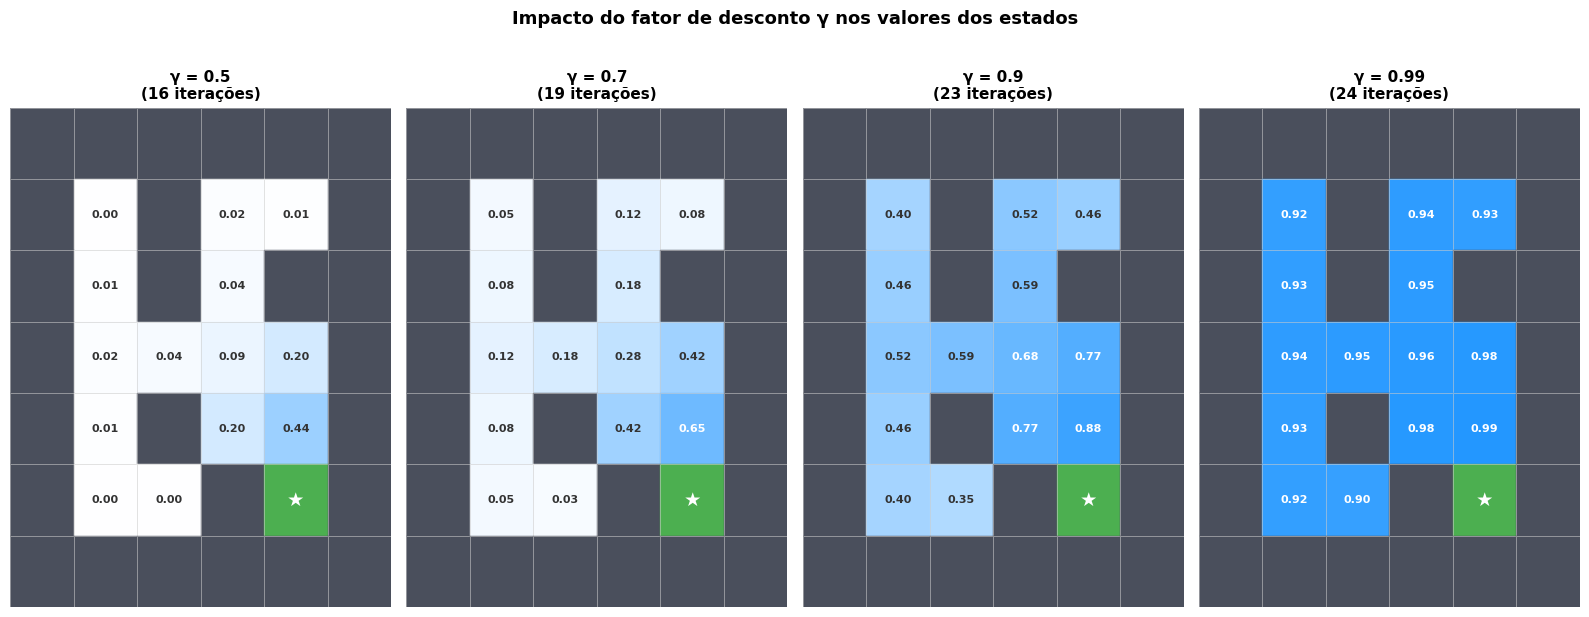

In [21]:
gammas = [0.5, 0.7, 0.9, 0.99]
fig, axes = plt.subplots(1, len(gammas), figsize=(16, 6))

for ax, g in zip(axes, gammas):
    # SEU CÓDIGO AQUI:
    # 1. Inicialize V_g = np.zeros((num_rows, num_cols))
    # 2. Rode o Value Iteration usando gamma = g (não o global)
    #    Dica: recalcule 'valor' dentro do loop com g no lugar de gamma
    # 3. Conte as iterações em n_iter
    # 4. Desenhe o mapa no subplot ax com o código abaixo

    V_g = np.zeros((num_rows, num_cols))
    n_iter = 0
    # ... seu loop aqui ...
    threshold = 1e-6

    def calcular_valor_local(estado, acao, current_V_g):
        row_l, col_l = estado

        if maze[row_l, col_l] == 9:  return 1.0
        if maze[row_l, col_l] == 1:  return 0.0
        proximo_l = (row_l, col_l)
        if acao == 'up':
            proximo_l = (max(row_l - 1, 0), col_l)
        elif acao == 'down':
            proximo_l = (min(row_l + 1, num_rows - 1), col_l)
        elif acao == 'left':
            proximo_l = (row_l, max(col_l - 1, 0))
        elif acao == 'right':
            proximo_l = (row_l, min(col_l + 1, num_cols - 1))

        if maze[proximo_l[0], proximo_l[1]] == 1:
            proximo_l = (row_l, col_l)

        valor_l = g * (p_sucesso * current_V_g[proximo_l[0], proximo_l[1]] +
                     p_falha   * current_V_g[row_l, col_l])
        return valor_l

    def melhor_acao_local(estado, current_V_g):
        acoes = ['up', 'down', 'left', 'right']
        melhor_v_l = -float('inf')
        melhor_a_l = None
        for acao_l in acoes:
            v_l = calcular_valor_local(estado, acao_l, current_V_g)
            if v_l > melhor_v_l:
                melhor_v_l = v_l
                melhor_a_l = acao_l
        return melhor_a_l, melhor_v_l

    # Value Iteration loop
    while True:
        delta = 0
        novo_V_g = V_g.copy()

        for row in range(num_rows):
            for col in range(num_cols):
                if maze[row, col] != 1:   # Ignora paredes
                    v_antigo = V_g[row, col]
                    _, valor = melhor_acao_local((row, col), V_g)
                    novo_V_g[row, col] = valor
                    delta = max(delta, abs(v_antigo - valor))

        V_g = novo_V_g
        n_iter += 1

        if delta < threshold:
            break


    # Desenhar no subplot (não modifique)
    arrows = {'up':'↑','down':'↓','left':'←','right':'→'}
    for row in range(num_rows):
        for col in range(num_cols):
            val = maze[row, col]
            if val == 1:
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color='#4a4f5c'))
            elif val == 9:
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color='#4CAF50'))
                ax.text(col+0.5, num_rows-row-0.5, '★', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold')
            else:
                v = V_g[row, col]
                intensity = min(max(v, 0), 1)
                r2 = int(255*(1-intensity*0.87))
                g2 = int(255*(1-intensity*0.41))
                color = f'#{r2:02x}{g2:02x}ff'
                ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1, color=color))
                txt_c = 'white' if intensity > 0.6 else '#333'
                ax.text(col+0.5, num_rows-row-0.5, f'{v:.2f}',
                        ha='center', va='center', fontsize=8, color=txt_c, fontweight='bold')
            ax.add_patch(plt.Rectangle((col, num_rows-row-1), 1, 1,
                                       fill=False, edgecolor='#ccc', linewidth=0.4))
    ax.set_xlim(0, num_cols)
    ax.set_ylim(0, num_rows)
    ax.set_title(f'γ = {g}\n({n_iter} iterações)', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Impacto do fator de desconto γ nos valores dos estados',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<details>
<summary> Dica</summary>

Dentro do loop de Value Iteration, troque `gamma` por `g` na equação de Bellman:

```python
valor = g * (p_sucesso * V_g[proximo[0], proximo[1]] +
             p_falha   * V_g[row, col])
```

Você pode criar uma versão local de `calcular_valor` que recebe `g` como parâmetro, ou copiar o loop do Exercício 9 trocando `gamma` por `g`.
</details>

---
##  Reflexão Final

Responda as perguntas abaixo (clique duas vezes para editar):

**1. O que acontece com os valores V(s) quando gamma é muito pequeno (ex: 0.5)?**

> *Sua resposta aqui...*

**2. Por que estados mais distantes do objetivo têm valores menores?**

> *Sua resposta aqui...*

**3. Na Cadeia de Markov do estudante, qual estado você esperaria ser o mais frequente no longo prazo? Isso se confirmou na simulação?**

> *Sua resposta aqui...*

**4. Qual a diferença entre uma Cadeia de Markov (exemplo 1) e um MDP (exemplo 2)?**

> *Sua resposta aqui...*

---
**Parabéns por concluir os exercícios!**

Você implementou do zero os blocos fundamentais de um MDP:
- Matriz de transição e simulação estocástica
- Equação de Bellman
- Value Iteration com convergência
- Análise do fator de desconto γ

Na próxima aula veremos como aprender essas mesmas políticas **sem conhecer P(s'|s,a)** — chegando ao **Q-Learning**!